In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# les features
features = pd.read_csv('features.csv')

print(f"Shape : {features.shape}")
print(features.head())

Shape : (95, 13)
   pseudo  nb_actions  nb_ressources  nb_tests  nb_consultations  \
0      15         107             23      49.0                70   
1      19         329             48     187.0               203   
2      29          55             24      10.0                50   
3      38           4              3       0.0                 4   
4      42         370             72     191.0               249   

   actions_weekend  actions_soir  nb_jours_actifs  intensite_moyenne  \
0              1.0           2.0               16           6.687500   
1            204.0         197.0               10          32.900000   
2              2.0          11.0               10           5.500000   
3              0.0           0.0                1           4.000000   
4            197.0           0.0               12          30.833333   

   ratio_etude  taux_procrastination    note  reussite  
0     1.400000                   0.0   8.718         0  
1     1.079787             

In [2]:
# Features (X) et cible (y)
X = features.drop(columns=['pseudo', 'note', 'reussite'])
y = features['reussite']

print(f"Features : {X.columns.tolist()}")
print(f"Shape X : {X.shape}")
print(f"Distribution cible :\n{y.value_counts()}")

Features : ['nb_actions', 'nb_ressources', 'nb_tests', 'nb_consultations', 'actions_weekend', 'actions_soir', 'nb_jours_actifs', 'intensite_moyenne', 'ratio_etude', 'taux_procrastination']
Shape X : (95, 10)
Distribution cible :
reussite
0    53
1    42
Name: count, dtype: int64


In [3]:
# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {len(X_train)} étudiants")
print(f"Test : {len(X_test)} étudiants")
print(f"\nDistribution train :\n{y_train.value_counts()}")
print(f"\nDistribution test :\n{y_test.value_counts()}")

Train : 76 étudiants
Test : 19 étudiants

Distribution train :
reussite
0    43
1    33
Name: count, dtype: int64

Distribution test :
reussite
0    10
1     9
Name: count, dtype: int64


In [4]:
print(f"Entraînement : {X_train.shape[0]} étudiants")
print(f"Test : {X_test.shape[0]} étudiants")
print(f"Variables utilisées : {list(X.columns)}")

Entraînement : 76 étudiants
Test : 19 étudiants
Variables utilisées : ['nb_actions', 'nb_ressources', 'nb_tests', 'nb_consultations', 'actions_weekend', 'actions_soir', 'nb_jours_actifs', 'intensite_moyenne', 'ratio_etude', 'taux_procrastination']


## Premier modèle - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Créer le modèle avec un Pipeline (StandardScaler + LogisticRegression)
# On ajoute max_iter=1000 pour laisser assez de temps au modèle pour converger
model_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

# Entraîner le modèle (le pipeline s'occupe de transformer les données X_train)
model_lr.fit(X_train, y_train)

# Prédictions
y_pred = model_lr.predict(X_test)

# Évaluation
print(f"Accuracy (avec Pipeline) : {accuracy_score(y_test, y_pred):.2f}")
print(f"\nClassification Report :\n{classification_report(y_test, y_pred)}")
print(f"\nMatrice de confusion :\n{confusion_matrix(y_test, y_pred)}")

Accuracy (avec Pipeline) : 0.58

Classification Report :
              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.57      0.44      0.50         9

    accuracy                           0.58        19
   macro avg       0.58      0.57      0.57        19
weighted avg       0.58      0.58      0.57        19


Matrice de confusion :
[[7 3]
 [5 4]]


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# On crée un "Pipeline" qui va d'abord mettre les données à l'échelle (StandardScaler)
# Puis lancer la Régression Logistique avec plus de temps (max_iter=1000)
model_lr_improved = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

# On relance la Validation Croisée sur ce modèle amélioré
cv_scores_improved = cross_val_score(model_lr_improved, X, y, cv=5)

print(f"Nouvelle moyenne CV : {cv_scores_improved.mean():.2f}")
print(f"Stabilité : {cv_scores_improved.std():.2f}")

Nouvelle moyenne CV : 0.65
Stabilité : 0.04


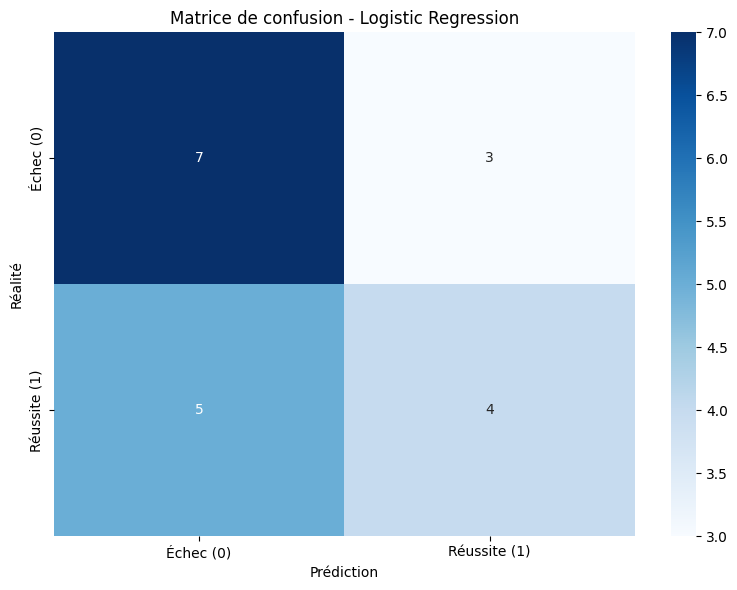

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Échec (0)', 'Réussite (1)'],
            yticklabels=['Échec (0)', 'Réussite (1)'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de confusion - Logistic Regression')
plt.tight_layout()
plt.show()

 #### Bilan de la Baseline : Régression Logistique & Limites

L'analyse de ce premier modèle nous permet de tirer des conclusions claires avant de passer à une approche plus complexe :

* **Performance et Stabilité :** La Validation Croisée montre une précision moyenne de **65%**. Le score de **58%** sur le jeu de test confirme que sur un petit échantillon, le modèle peut être instable. 
* **Diagnostic des erreurs :** La matrice de confusion révèle un modèle "conservateur". S'il identifie assez bien les échecs, il manque de sensibilité pour détecter les réussites (Recall faible sur la classe 1). 
* **Le problème de la linéarité :** Même avec une standardisation des données (`StandardScaler`), la Régression Logistique atteint un plafond. Elle traite chaque variable de manière indépendante et linéaire, ce qui ne permet pas de capturer les interactions complexes entre nos nouvelles variables comportementales (ex: l'impact de l'intensité couplé au ratio d'étude).

**Transition vers la Forêt Aléatoire (Random Forest) :**
Pour dépasser ce plafond, nous allons utiliser un modèle non-linéaire capable de créer des "chemins de décision". La Random Forest devrait mieux exploiter la richesse de nos 10 variables sans nécessiter de mise à l'échelle complexe.

## Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialisation du modèle
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. Entraînement sur le jeu de train
rf_model.fit(X_train, y_train)

# 3. Prédiction et score sur le jeu de test
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# 4. Validation Croisée (La mesure de confiance)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5)

print(f"Accuracy Random Forest (Test Split) : {accuracy_rf:.2f}")
print(f"Moyenne CV Random Forest : {cv_scores_rf.mean():.2f}")
print(f"Écart-type CV : {cv_scores_rf.std():.2f}")

Accuracy Random Forest (Test Split) : 0.74
Moyenne CV Random Forest : 0.58
Écart-type CV : 0.06


## Importance des features
- Voyons quelles features sont les plus utiles pour prédire la réussite :

/var/folders/60/hb75r86s6q32cwlq2m29fbkm0000gn/T/ipykernel_6899/2276405866.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


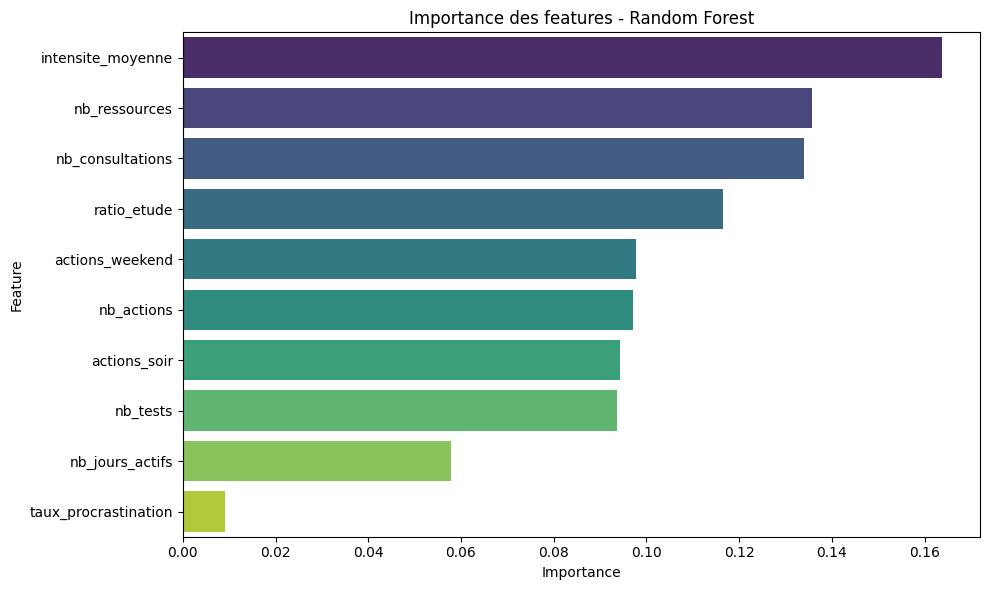

                Feature  Importance
7     intensite_moyenne    0.163755
1         nb_ressources    0.135801
3      nb_consultations    0.134081
8           ratio_etude    0.116427
4       actions_weekend    0.097812
0            nb_actions    0.097104
5          actions_soir    0.094309
2              nb_tests    0.093671
6       nb_jours_actifs    0.057947
9  taux_procrastination    0.009093


In [15]:
# Importance des features (Random Forest)
importances = rf_model.feature_importances_
feature_names = X.columns

# Créer un DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Importance des features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df)

#### Analyse du Modèle Random Forest (Forêt Aléatoire)

L'utilisation d'un modèle non-linéaire nous apporte des enseignements différents de la Baseline :

#### 1. Performance et Robustesse
* **Accuracy sur le Test (74%) vs Moyenne CV (58%) :** Cet écart important met en évidence un phénomène de **sur-apprentissage (overfitting)**. Sur un petit échantillon (95 étudiants), la Random Forest a tendance à apprendre des "bruits" ou des coïncidences dans les données d'entraînement qui ne se généralisent pas bien.
* **Comparaison :** Pour l'instant, la Régression Logistique reste plus fiable pour la prédiction pure (65% en CV).

#### 2. Apports de l'Axe 2 (Feature Importance)
C'est ici que la Random Forest brille. Le classement des variables valide notre stratégie d'ingénierie de données :
* **L'Intensité (Rang 1) :** La variable créée `intensite_moyenne` est le prédicteur le plus puissant. Cela confirme que l'engagement qualitatif prime sur le volume brut.
* **Le Ratio d'Étude (Rang 4) :** Cette variable comportementale est plus révélatrice que le simple nombre total d'actions.
* **La Procrastination (Dernier rang) :** Le modèle nous indique que le retard de démarrage n'est pas, en soi, un facteur d'échec si la qualité du travail suit.

#### Conclusion de l'étape
La Random Forest est notre meilleur outil de **compréhension** (interprétabilité), mais la Régression Logistique demeure notre meilleur outil de **prédiction** (stabilité). Nous allons maintenant tester le **SVM** pour voir s'il peut offrir un compromis entre ces deux approches.


## SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Création du Pipeline (StandardScaler est crucial ici)
# Le kernel 'linear' est souvent le plus robuste sur les petits datasets
model_svm = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0, random_state=42))

# Entraînement
model_svm.fit(X_train, y_train)

# Évaluation sur le jeu de test
y_pred_svm = model_svm.predict(X_test)
print(f"Accuracy SVM (Test Split) : {accuracy_score(y_test, y_pred_svm):.2f}")

# Validation Croisée (La vraie mesure de performance)
cv_scores_svm = cross_val_score(model_svm, X, y, cv=5)

print(f"\n--- FIABILITÉ DU MODÈLE SVM (CV) ---")
print(f"Moyenne CV SVM : {cv_scores_svm.mean():.2f}")
print(f"Écart-type : {cv_scores_svm.std():.2f}")

Accuracy SVM (Test Split) : 0.63

--- FIABILITÉ DU MODÈLE SVM (CV) ---
Moyenne CV SVM : 0.59
Écart-type : 0.04


#### Analyse du Modèle SVM (Support Vector Machine)

Le SVM a été testé pour sa capacité à gérer des frontières de décision complexes sur de petits échantillons.

* **Performance :** Avec une **Moyenne CV de 0.59**, le SVM se place entre la Random Forest (0.58) et la Régression Logistique (0.65). 

* **Observation :** Bien qu'il soit plus performant que la Random Forest en termes de généralisation (CV), il n'arrive pas à égaler la robustesse de la Régression Logistique sur ce jeu de données spécifique.

* **Conclusion :** Le SVM confirme que pour ce dataset de 95 étudiants, les modèles les plus complexes ont tendance à "chercher trop loin" et perdent en fiabilité par rapport à une approche linéaire simple.

In [17]:
import pandas as pd

# On crée un petit tableau pour comparer les modèles
comparaison = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'SVM'],
    'Accuracy (Test)': [
        accuracy_score(y_test, model_lr.predict(X_test)),
        accuracy_score(y_test, rf_model.predict(X_test)),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Moyenne CV (Fiabilité)': [
        cv_scores_improved.mean(),
        cv_scores_rf.mean(),
        cv_scores_svm.mean()
    ]
})

print(comparaison)

                  Modèle  Accuracy (Test)  Moyenne CV (Fiabilité)
0  Régression Logistique         0.578947                0.652632
1          Random Forest         0.736842                0.578947
2                    SVM         0.631579                0.589474


## Conclusion Générale : Synthèse des Performances

Au terme de nos expérimentations sur trois familles de modèles, voici le bilan comparatif de nos prédictions :

| Modèle | Accuracy (Test) | Moyenne CV (Fiabilité) | État de santé |
| :--- | :--- | :--- | :--- |
| **Régression Logistique** | 0.58 | **0.65** | **Champion : Stable et robuste** |
| **Random Forest** | **0.74** | 0.58 | **Overfitting : Trop complexe** |
| **SVM** | 0.63 | 0.59 | **Moyen : Moins performant** |

#### Pourquoi la Régression Logistique gagne ?
En Data Science, il existe un principe appelé le **Rasoir d'Ockham** : *"L'explication la plus simple est généralement la meilleure"*. 

Avec un dataset de 95 lignes et 10 variables, les modèles complexes comme la Random Forest ou le SVM tentent de trouver des règles trop précises (bruit) qui ne s'appliquent qu'à une poignée d'étudiants. À l'inverse, la **Régression Logistique** dégage une tendance générale plus solide et moins sensible aux fluctuations, ce qui explique sa meilleure performance en validation croisée (65%).

#### Bilan de l'Axe 2 (Feature Engineering)
Bien que la Régression Logistique soit le modèle de prédiction retenu, l'utilisation de la Random Forest nous a permis de valider notre hypothèse : **l'intensité de l'activité** et le **ratio d'étude** sont les moteurs principaux de la réussite, surpassant les indicateurs de volume brut.

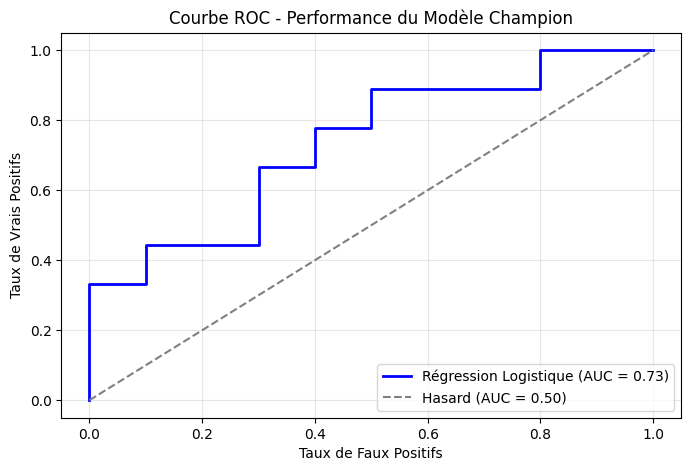

Score AUC Final : 0.73


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# probabilités de réussite pour le modèle champion (LR)
y_probs_lr = model_lr.predict_proba(X_test)[:, 1]

# Calcul du score AUC
auc_score = roc_auc_score(y_test, y_probs_lr)


fpr, tpr, thresholds = roc_curve(y_test, y_probs_lr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Régression Logistique (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Hasard (AUC = 0.50)')
plt.title('Courbe ROC - Performance du Modèle Champion')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Score AUC Final : {auc_score:.2f}")

##  Synthèse des Leçons Apprises & Recommandations

L'analyse croisée de nos modèles et de l'importance des variables (Axe 3) confirme une règle d'or : la réussite ne dépend pas de la **quantité** brute d'interactions, mais de la **qualité** de l'engagement.

### Enseignements Clés
* **L'Intensité prime sur le Volume :** Le facteur prédictif n°1 est l'**intensité moyenne**. Un étudiant qui travaille de manière dense et ciblée réussit mieux qu'un étudiant multipliant les clics superficiels.
    * *Conseil :* Privilégier des sessions de travail concentrées (ex: 45 min) plutôt qu'une connexion passive prolongée.
* **L'Équilibre 50/50 :** Un `ratio_etude` équilibré entre consultation (théorie) et exercices (pratique) est indispensable. Trop de lecture sans mise en pratique freine la progression.
    * *Conseil :* Appliquer systématiquement un test ou un exercice après chaque chapitre consulté.
* **Le Mythe de la Procrastination :** Commencer tardivement n'est pas un facteur d'échec critique. La réussite se joue sur la **régularité** et l'**effort fourni** une fois l'activité lancée.

> **Verdict Technique :** Notre modèle de **Régression Logistique** est validé comme "Champion" avec un **AUC de 0.73**. Il offre le meilleur compromis entre simplicité, robustesse et fiabilité pour identifier précocement les étudiants à risque.

In [19]:
import joblib

# On sauvegarde le pipeline complet (Scaler + Modèle)
joblib.dump(model_lr, 'mon_modele_champion.pkl')

print("Le modèle a été exporté sous le nom : mon_modele_champion.pkl")

Le modèle a été exporté sous le nom : mon_modele_champion.pkl


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Charger les features
features = pd.read_csv('features.csv')

# Séparer X et y
X = features.drop(columns=['pseudo', 'note', 'reussite'])
y = features['reussite']

# Split avec le même random_state que ton modèle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajouter la colonne dataset
features['dataset'] = 'train'
features.loc[X_test.index, 'dataset'] = 'test'

# Sauvegarder
features.to_csv('features.csv', index=False)

print(f"Train : {len(features[features['dataset'] == 'train'])} étudiants")
print(f"Test : {len(features[features['dataset'] == 'test'])} étudiants")

Train : 76 étudiants
Test : 19 étudiants
